In [3]:
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns
import pandas as pd
from PIL import Image

In [4]:
root_path = r"D:\Project\CPV_paper\datasets\raw\PACS\Raw images\kfold"
root = os.listdir(root_path)

In [5]:
rows = []

for domain in os.listdir(root_path):
    domain_path = os.path.join(root_path, domain)

    if not os.path.isdir(domain_path):
        continue

    for category in os.listdir(domain_path):
        category_path = os.path.join(domain_path, category)

        if not os.path.isdir(category_path):
            continue

        for image in os.listdir(category_path):
            image_path = os.path.join(category_path, image)

            if not os.path.isfile(image_path):
                continue

            rows.append({
                "image_path": image_path,
                "image_name": image,
                "domain": domain,
                "category": category
            })

df = pd.DataFrame(rows)

df.head()

,image_path,image_name,domain,category
0,D:\Project\CPV_paper\datasets\raw\PACS\Raw ima...,pic_001.jpg,art_painting,dog
1,D:\Project\CPV_paper\datasets\raw\PACS\Raw ima...,pic_002.jpg,art_painting,dog
2,D:\Project\CPV_paper\datasets\raw\PACS\Raw ima...,pic_003.jpg,art_painting,dog
3,D:\Project\CPV_paper\datasets\raw\PACS\Raw ima...,pic_004.jpg,art_painting,dog
4,D:\Project\CPV_paper\datasets\raw\PACS\Raw ima...,pic_005.jpg,art_painting,dog


In [6]:
print(f"""
Number of domains: {len(df['domain'].unique())}
{df['domain'].unique()}

Number of categories: {len(df['category'].unique())}
{df['category'].unique()}

Number of images: {len(df)}
""")


Number of domains: 4
['art_painting' 'cartoon' 'photo' 'sketch']

Number of categories: 7
['dog' 'elephant' 'giraffe' 'guitar' 'horse' 'house' 'person']

Number of images: 9991



In [7]:
def bar_plot(x, y, x_label, y_label, title, data):
    plt.figure(figsize=(20, 5))
    sns.barplot(x=x, y=y, data=data, hue=x, palette='viridis')
    plt.xlabel(x_label)    
    plt.ylabel(y_label)
    plt.title(title)
    plt.tight_layout()
    plt.plot()


Image per domain:
         domain  count
0        sketch   3929
1       cartoon   2344
2  art_painting   2048
3         photo   1670

Largest domain:
domain    0
count     0
dtype: int64

Smallest domain:
domain    2
count     3
dtype: int64

Imbalance ratio:
2.35



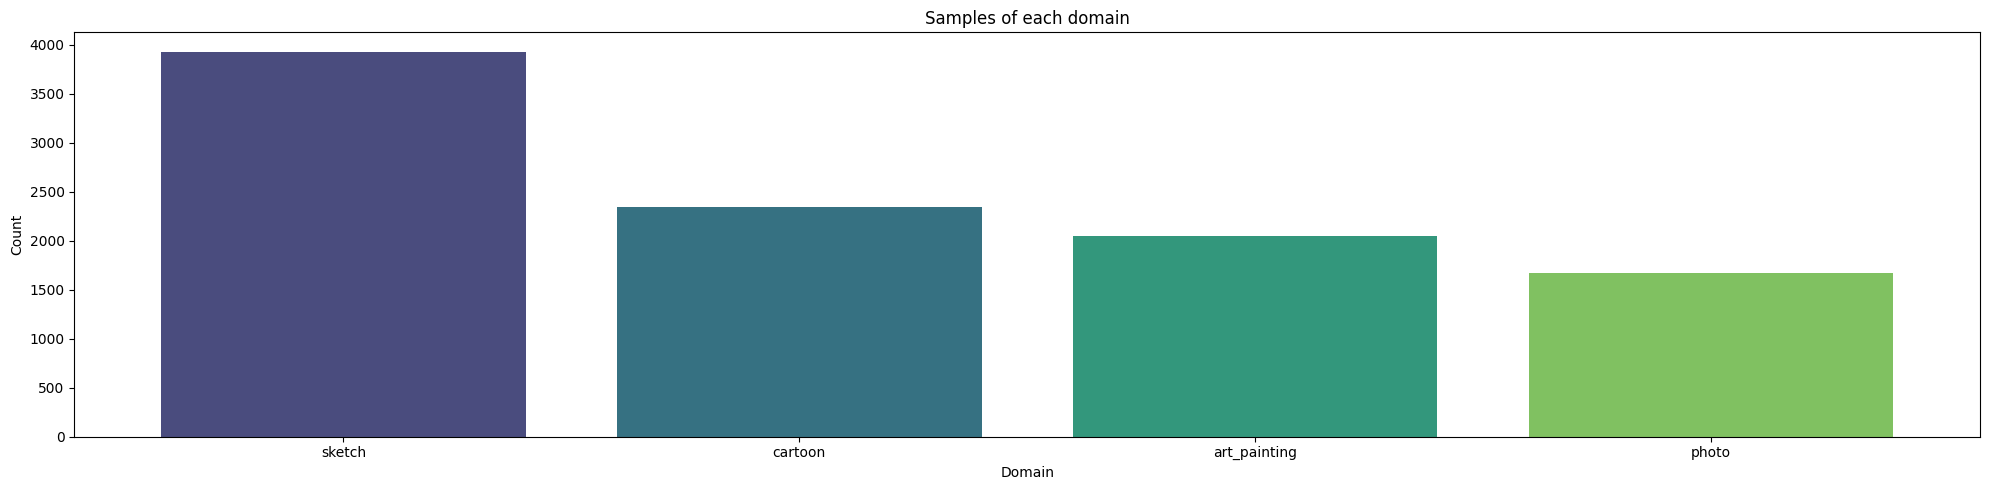

In [8]:
domain_counts = df['domain'].value_counts().reset_index()

print(f"""
Image per domain:
{domain_counts}

Largest domain:
{domain_counts.idxmax()}

Smallest domain:
{domain_counts.idxmin()}

Imbalance ratio:
{domain_counts['count'].max() / domain_counts['count'].min():.2f}
""")

bar_plot('domain', 'count', 'Domain', 'Count', 'Samples of each domain', domain_counts)


Top frequent classes:
   category  count
0       dog   1729
1  elephant   1654
2   giraffe   1566
3     horse   1540
4    person   1446
5    guitar   1113
6     house    943

Rare classes:
   category  count
0       dog   1729
1  elephant   1654
2   giraffe   1566
3     horse   1540
4    person   1446
5    guitar   1113
6     house    943

Imbalance ratio:
1.83



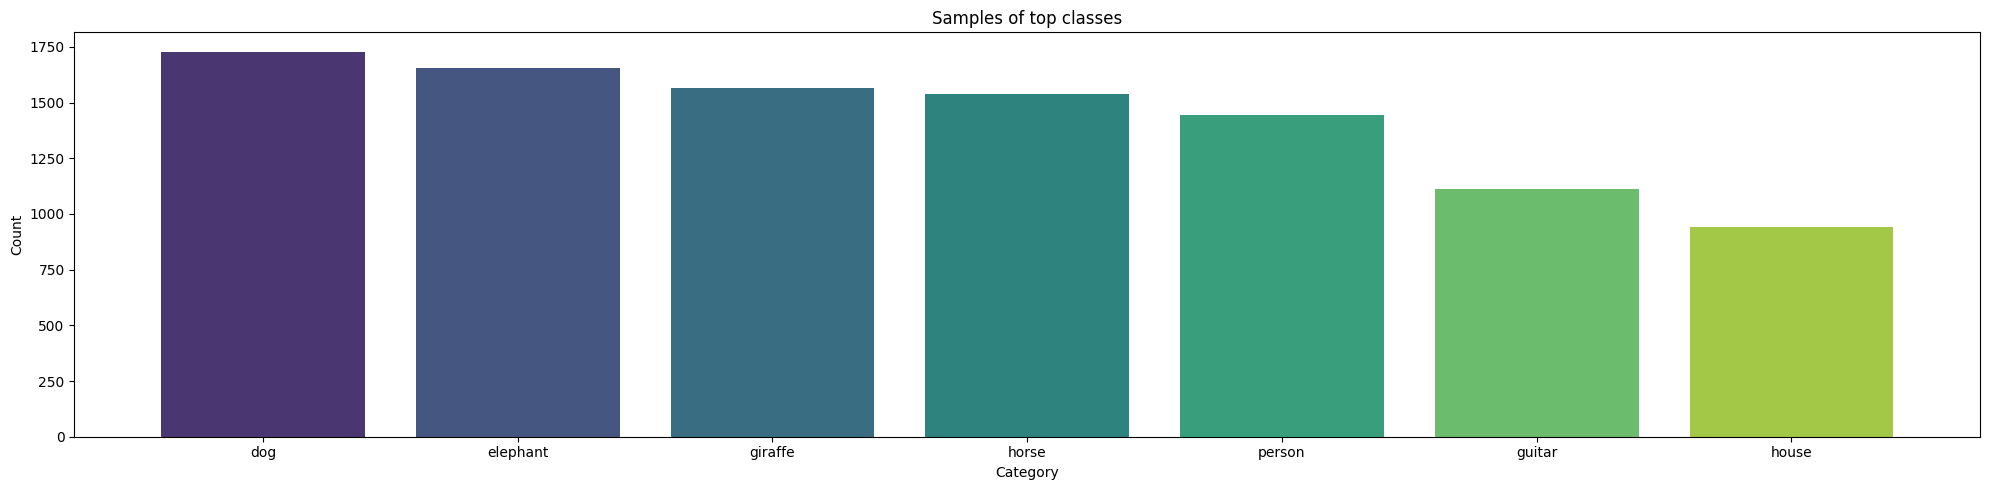

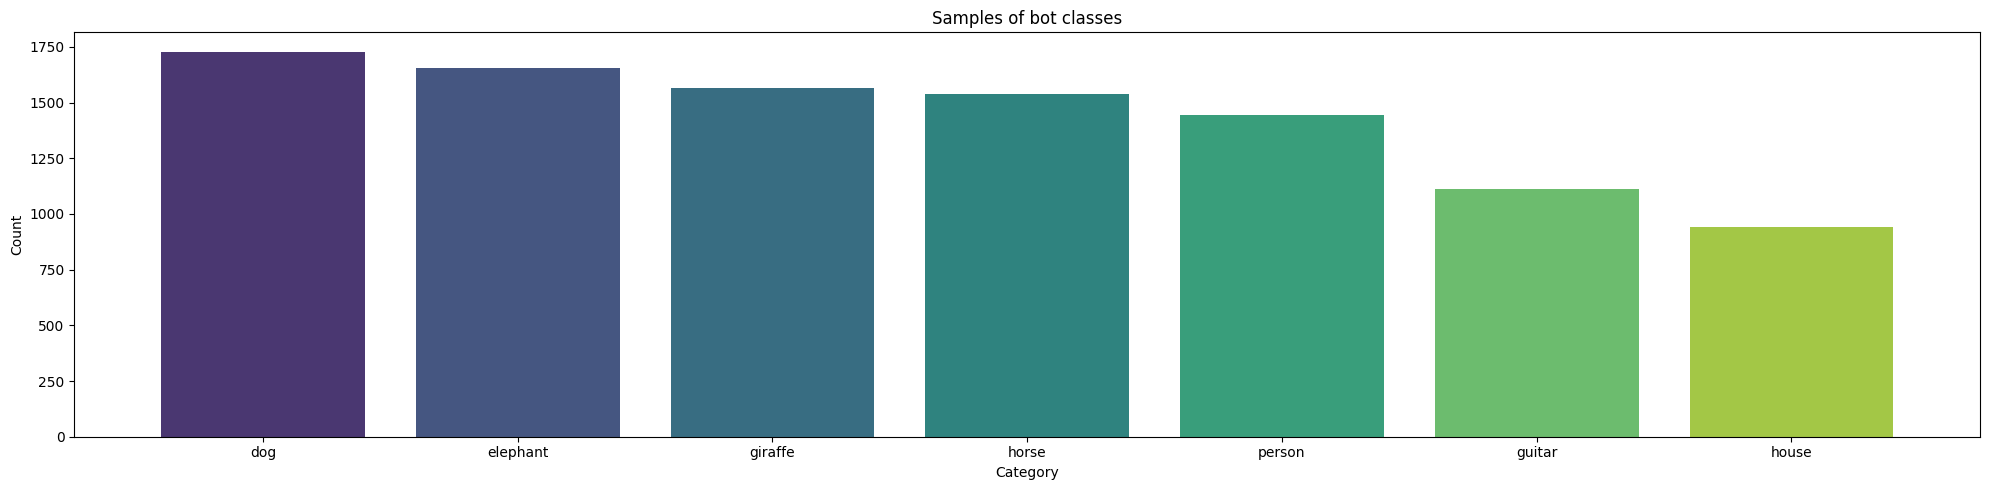

In [9]:
class_counts = df['category'].value_counts().reset_index()

print(f"""
Top frequent classes:
{class_counts.head(10)}

Rare classes:
{class_counts.tail(10)}

Imbalance ratio:
{class_counts['count'].max() / class_counts['count'].min():.2f}
""")

bar_plot('category', 'count', 'Category', 'Count', 'Samples of top classes', class_counts.head(10))
bar_plot('category', 'count', 'Category', 'Count', 'Samples of bot classes', class_counts.tail(10))

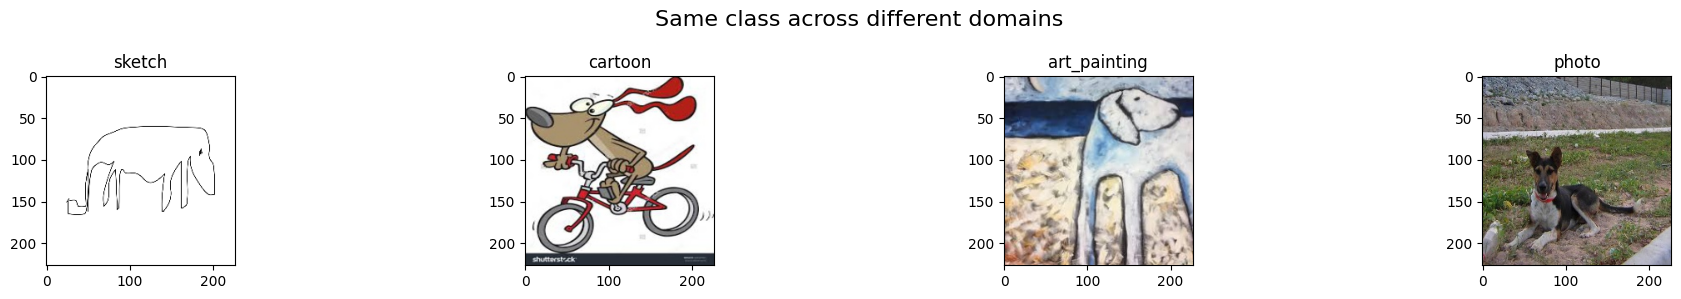

In [10]:
idx = 67
fig, ax = plt.subplots(1, 4, figsize=(20, 3))

ax[0].imshow(Image.open(df[(df['category'] == 'dog') & (df['domain'] == 'sketch')]['image_path'].iloc[idx]))
ax[0].set_title('sketch')

ax[1].imshow(Image.open(df[(df['category'] == 'dog') & (df['domain'] == 'cartoon')]['image_path'].iloc[idx]))
ax[1].set_title('cartoon')

ax[2].imshow(Image.open(df[(df['category'] == 'dog') & (df['domain'] == 'art_painting')]['image_path'].iloc[idx]))
ax[2].set_title('art_painting')

ax[3].imshow(Image.open(df[(df['category'] == 'dog') & (df['domain'] == 'photo')]['image_path'].iloc[idx]))
ax[3].set_title('photo')

plt.suptitle("Same class across different domains", fontsize=16)
plt.tight_layout()
plt.show()

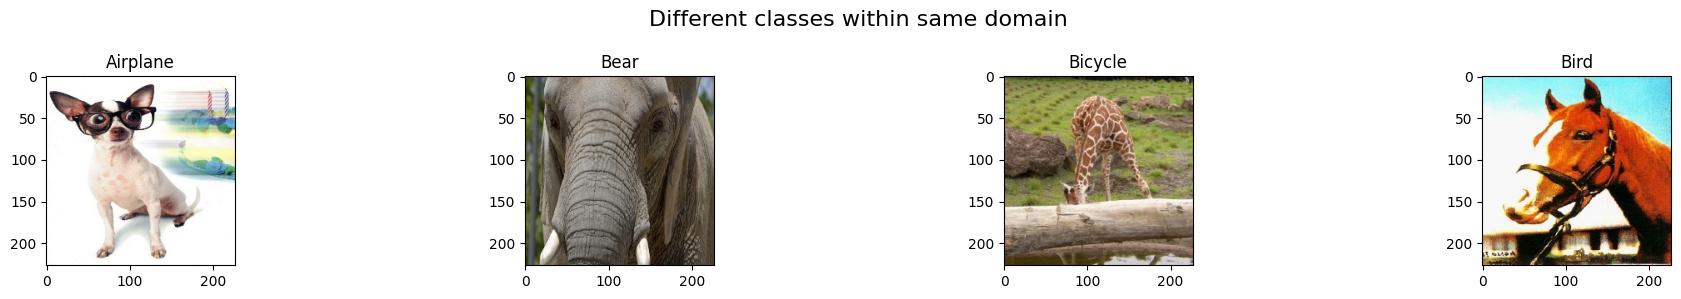

In [11]:
idx = 36
fig, ax = plt.subplots(1, 4, figsize=(20, 3))

ax[0].imshow(Image.open(df[(df['category'] == 'dog') & (df['domain'] == 'photo')]['image_path'].iloc[idx]))
ax[0].set_title('Airplane')

ax[1].imshow(Image.open(df[(df['category'] == 'elephant') & (df['domain'] == 'photo')]['image_path'].iloc[idx]))
ax[1].set_title('Bear')

ax[2].imshow(Image.open(df[(df['category'] == 'giraffe') & (df['domain'] == 'photo')]['image_path'].iloc[idx]))
ax[2].set_title('Bicycle')

ax[3].imshow(Image.open(df[(df['category'] == 'horse') & (df['domain'] == 'photo')]['image_path'].iloc[idx]))
ax[3].set_title('Bird')

plt.suptitle("Different classes within same domain", fontsize=16)
plt.tight_layout()
plt.show()

In [12]:
widths, heights, aspect_ratios, corrupt = [], [], [], []

for path in df['image_path']:
    try:
        with Image.open(path) as img:
            img.verify()

        with Image.open(path) as img:
            w, h = img.size

        widths.append(w)
        heights.append(h)
        aspect_ratios.append(w/h)
        corrupt.append(False)

    except Exception:
        widths.append(None)
        heights.append(None)
        aspect_ratios.append(None)
        corrupt.append(True)

df = df.copy()
df["width"] = widths
df["height"] = heights
df["aspect_ratio"] = aspect_ratios
df["corrupt"] = corrupt

In [13]:
df.head()

,image_path,image_name,domain,category,width,height,aspect_ratio,corrupt
0,D:\Project\CPV_paper\datasets\raw\PACS\Raw ima...,pic_001.jpg,art_painting,dog,227,227,1.0,False
1,D:\Project\CPV_paper\datasets\raw\PACS\Raw ima...,pic_002.jpg,art_painting,dog,227,227,1.0,False
2,D:\Project\CPV_paper\datasets\raw\PACS\Raw ima...,pic_003.jpg,art_painting,dog,227,227,1.0,False
3,D:\Project\CPV_paper\datasets\raw\PACS\Raw ima...,pic_004.jpg,art_painting,dog,227,227,1.0,False
4,D:\Project\CPV_paper\datasets\raw\PACS\Raw ima...,pic_005.jpg,art_painting,dog,227,227,1.0,False


In [14]:
print(f"""
Image sizes stats:
{df[["width", "height", "aspect_ratio"]].describe()}

Corrupt images:
{df[df["corrupt"] == True][["image_path", "domain", "category"]]}

Small images:
{df[(df["width"] < 32) | (df["height"] < 32)][["image_path", "domain", "category", "width", "height"]]}

Strange aspect ratios images:
{df[(df["aspect_ratio"] < 0.3) | (df["aspect_ratio"] > 3.0)][["image_path", "domain", "category", "width", "height", "aspect_ratio"]].value_counts().sum()}
""")


Image sizes stats:
        width  height  aspect_ratio
count  9991.0  9991.0        9991.0
mean    227.0   227.0           1.0
std       0.0     0.0           0.0
min     227.0   227.0           1.0
25%     227.0   227.0           1.0
50%     227.0   227.0           1.0
75%     227.0   227.0           1.0
max     227.0   227.0           1.0

Corrupt images:
Empty DataFrame
Columns: [image_path, domain, category]
Index: []

Small images:
Empty DataFrame
Columns: [image_path, domain, category, width, height]
Index: []

Strange aspect ratios images:
0



In [15]:
split_path = r"D:\Project\CPV_paper\datasets\PACS\Train val splits and h5py files pre-read"
split = os.listdir(split_path)

FileNotFoundError: [WinError 3] The system cannot find the path specified: 'D:\\Project\\CPV_paper\\datasets\\PACS\\Train val splits and h5py files pre-read'

In [ ]:
rows = []

for txt in split:
    txt_path = os.path.join(split_path, txt)
    if txt.endswith('.txt') and txt != "readme.txt":
        domains = txt.split('_kfold.txt')[0]
        if "art_painting" in domains:
            domain = domains[:12]
            split2 = domains[13:]
        else:
            domain = domains.split('_')[0]
            split2 = domains.split('_')[1]

        if split2 == 'crossval':
            split2 = 'val'

        with open(txt_path, 'r') as f:
            contents = f.readlines()

            for content in contents:
                rows.append({
                    "image_path": content.split()[0],
                    "domain": domain,
                    "split": split2,
                    "label": content.split()[-1]
                })

In [ ]:
df = pd.DataFrame(rows)

df.head()

,image_path,domain,split,label
0,art_painting/dog/pic_225.jpg,art_painting,val,1
1,art_painting/dog/pic_249.jpg,art_painting,val,1
2,art_painting/dog/pic_306.jpg,art_painting,val,1
3,art_painting/dog/pic_241.jpg,art_painting,val,1
4,art_painting/dog/pic_219.jpg,art_painting,val,1


In [ ]:
print(f"""
Train size:
{len(df[df['split'] == 'train'])}

Test size:
{len(df[df['split'] == 'test'])}

Val size:
{len(df[df['split'] == 'val'])}

Class balance per split:
{pd.crosstab(df["label"], df["split"])}

Domain balance per split:
{pd.crosstab(df["domain"], df["split"])}
""")


Train size:
8977

Test size:
9991

Val size:
1014

Class balance per split:
split  test  train  val
label                  
1      1729   1555  174
2      1654   1486  168
3      1566   1407  159
4      1113   1000  113
5      1540   1384  156
6       943    846   97
7      1446   1299  147

Domain balance per split:
split         test  train  val
domain                        
art_painting  2048   1840  208
cartoon       2344   2107  237
photo         1670   1499  171
sketch        3929   3531  398

